# Loan approval prediction

In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

In [ ]:
# load the data
df = pd.read_csv("/content/loan_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

# EDA

In [ ]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
# handling outliers
df=df[df["person_age"]<100]
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44993.000000,4.499300e+04,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000
mean,27.748428,7.990845e+04,5.394528,9583.176761,11.006448,0.139736,5.866557,632.585713,0.222257
std,5.909737,6.332213e+04,5.927159,6314.802655,2.978985,0.087207,3.877167,50.402411,0.415767
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.719500e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704600e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.577800e+04,8.000000,12237.000000,12.990000,0.190000,8.000000,670.000000,0.000000
max,94.000000,2.448661e+06,76.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


<Axes: xlabel='loan_status', ylabel='Count'>

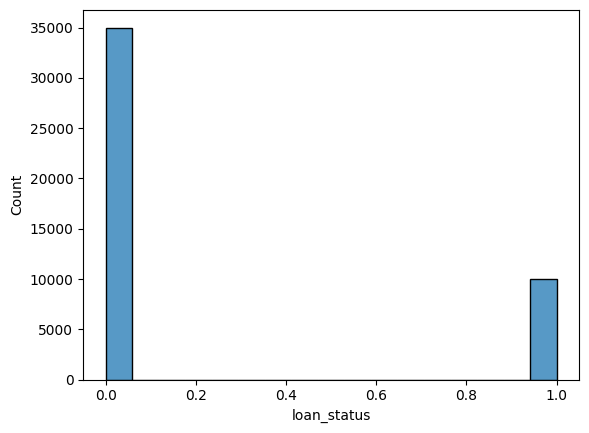

In [ ]:
# how many loans were approved vs not approved
sns.histplot(x="loan_status",data=df)

<Axes: xlabel='person_gender', ylabel='count'>

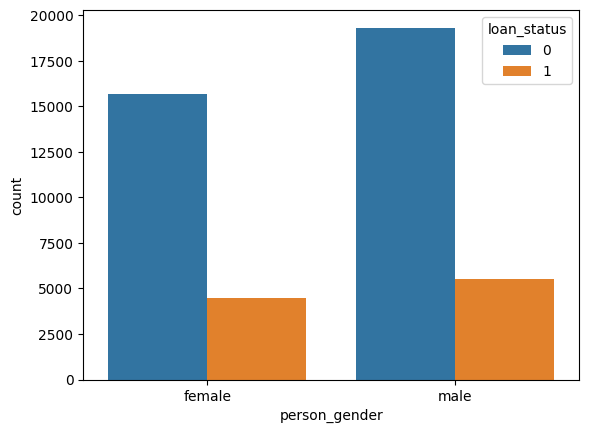

In [ ]:
# for each gender, how many loans were approved vs. not approved
sns.countplot(x="person_gender",data=df,hue="loan_status")

<Axes: xlabel='person_age', ylabel='Count'>

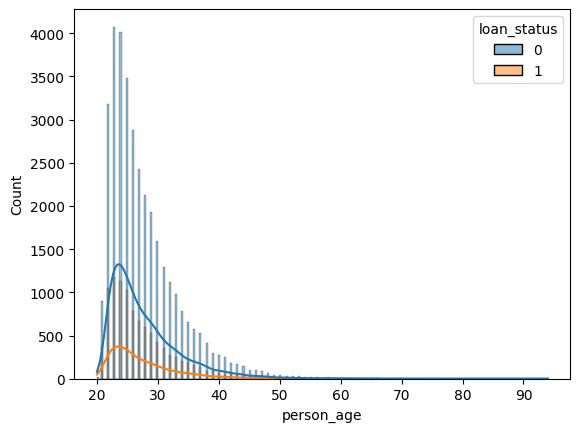

In [ ]:
# age group of people who are getting loan and not getting loan
sns.histplot(x="person_age",data=df,hue="loan_status",kde=True)

<Axes: xlabel='person_education', ylabel='count'>

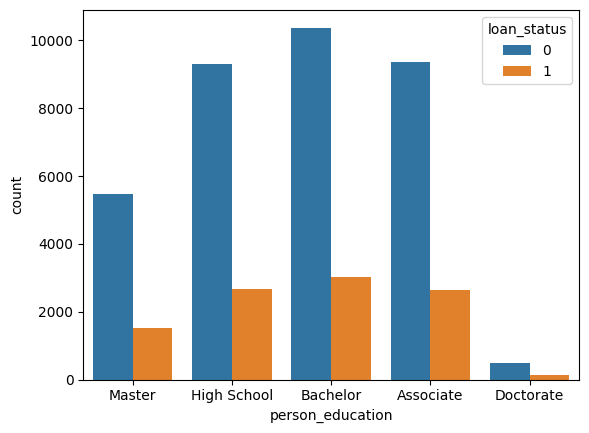

In [ ]:
# for each education category, how many loans were approved vs not approved
sns.countplot(x="person_education",data=df,hue="loan_status")

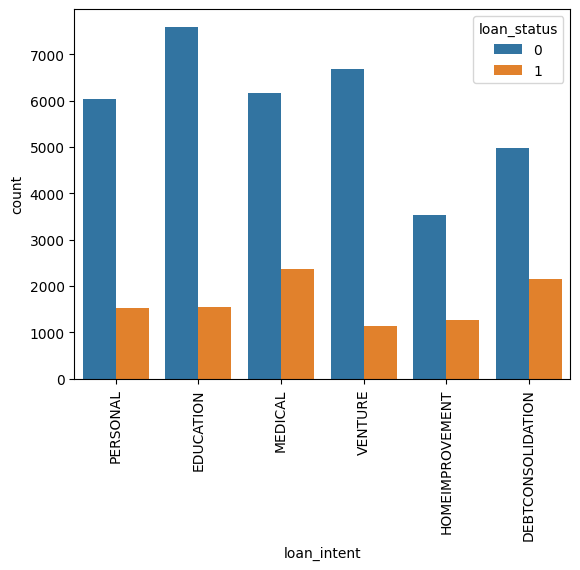

In [ ]:
# loan status for loan purpose
sns.countplot(x="loan_intent",data=df,hue="loan_status")
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='credit_score', ylabel='Count'>

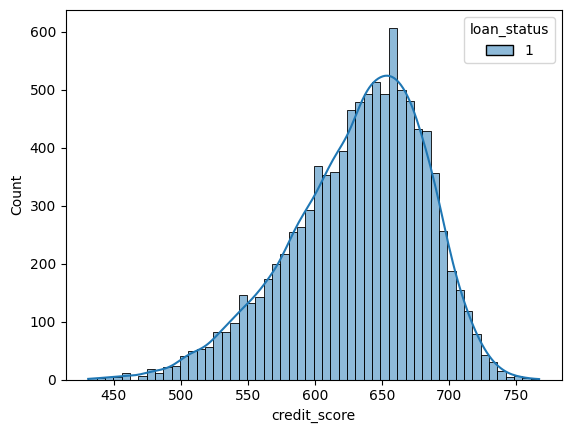

In [ ]:
# distribution of loan status as per credit score
sns.histplot(x="credit_score",data=df[df["loan_status"]==1],hue="loan_status",kde=True)

# Model Training

In [ ]:
# Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
  if df[col].dtype=="object":
    df[col] = le.fit_transform(df[col])
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,1,0,47971.0,6,3,15000.0,3,15.66,0.31,3.0,645,0,1
44996,37.0,0,0,65800.0,17,3,9000.0,2,14.07,0.14,11.0,621,0,1
44997,33.0,1,0,56942.0,7,3,2771.0,0,10.02,0.05,10.0,668,0,1
44998,29.0,1,1,33164.0,4,3,12000.0,1,13.23,0.36,6.0,604,0,1


In [ ]:
# Divide data into input and output
X=df.drop("loan_status",axis=1)
y=df["loan_status"]

In [ ]:
# split data for training and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
# scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
Xtrain = sc.fit_transform(Xtrain)
Xtest = sc.transform(Xtest)

In [ ]:
# model training
model = SVC(kernel = "rbf")
model.fit(Xtrain,ytrain)

SVC()

# Model Evaluation and tuning

In [ ]:
# prediction
ypred = model.predict(Xtest)
ypred

array([1, 0, 0, ..., 1, 0, 1])

In [ ]:
confusion_matrix(ytest,ypred)

array([[10044,   446],
       [  792,  2216]])

In [ ]:
# performance metrics
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94     10490
           1       0.83      0.74      0.78      3008

    accuracy                           0.91     13498
   macro avg       0.88      0.85      0.86     13498
weighted avg       0.91      0.91      0.91     13498



In [ ]:
# Efficiency
print("Training eff: ",model.score(Xtrain,ytrain))
print("Testing eff: ",model.score(Xtest,ytest))

Training eff:  0.9132560723924432
Testing eff:  0.9082827085494147


## This is a Generalized model

In [ ]:
# new input prediction
new_data = df.iloc[0:1,:-1]
new_data = sc.transform(new_data)
pred = model.predict(new_data)[0]
if pred == 1:
    print("Loan approved")
else:
    print("Loan not approved")

Loan approved
